# Space Object Classification using Satellite Catalog (SATCAT) Data

---
## PROBLEM STATEMENT

Thousands of objects, including satellites, rocket bodies, and space debris, orbit the Earth. As the number of these objects continues to grow, identifying and monitoring them manually becomes increasingly difficult. Unidentified or unmanaged objects can increase the risk of collisions and complicate space traffic management. Therefore, there is a need for automated methods to analyze the orbital and physical characteristics of space objects for efficient identification and classification.

---
## OBJECTIVE

The objective of this project is to analyze the orbital and physical characteristics of space objects, identify patterns that distinguish different object types, and develop a machine learning classification model to predict the type of a space object based on its orbital parameters. 

---
## DATASET OVERVIEW

The dataset contains information about artificial space objects, including satellites, rocket bodies, and debris, along with their orbital characteristics, ownership, launch details, and operational status.

Target Variable: OBJECT_TYPE

Machine Learning Task: Multi-class Classification

Feature Types:  
• Numerical  
• Categorical  
• Date/Time  

---
## FEATURE DESCRIPTION

| Column Name          | Description                                                                                                                                                                                      |
| -------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| OBJECT_NAME      | Name of the satellite, rocket body, or space object. Example: SPUTNIK 1, VANGUARD 1.                                                                                                         |
| OBJECT_ID        | International designator assigned to the object based on the launch year and launch sequence. Example: 1957-001B means the object was launched in 1957 during the first launch of that year. |
| NORAD_CAT_ID     | North American Aerospace Defense Command (NORAD) Catalog Identification Number. A unique number assigned to each space object for identification, tracking, and monitoring while it remains in orbit.|
| OBJECT_TYPE      | Type of the object. Examples: PAYLOAD (satellite), ROCKET BODY, DEBRIS, etc.                                                                                                         |
| OPS_STATUS_CODE  | Operational status of the object, indicating whether it is active, inactive, decayed, or unknown.                                                                                                |
| OWNER            | Country, government agency, or organization responsible for launching or owning the space object. The values are represented using standardized abbreviations (e.g., USA, CIS, PRC, IND, ESA).  |
| LAUNCH_DATE      | Date on which the object was launched into space.                                                                                                                                                |
| LAUNCH_SITE      | Launch facility or space center from where the object was launched.                                                                                                                              |
| DECAY_DATE       | Date when the object re-entered Earth's atmosphere and stopped orbiting, if applicable.                                                                                                          |
| PERIOD           | Time taken by the object to complete one orbit around Earth, usually measured in minutes.                                                                                                        |
| INCLINATION      | Angle between the object's orbit and Earth's equator, measured in degrees. It indicates how tilted the orbit is.                                                                                 |
| APOGEE           | Farthest point of the orbit from Earth, measured in kilometers.                                                                                                                                  |
| PERIGEE          | Closest point of the orbit to Earth, measured in kilometers.                                                                                                                                     |
| RCS              | Radar Cross Section (RCS) measures how detectable a space object is by radar. Larger RCS values generally indicate larger or more radar-reflective objects.                                    |
| DATA_STATUS_CODE | Indicates the availability or reliability of the orbital data using standardized status codes.                                                                                                               |
| ORBIT_CENTER     | Indicates the celestial body around which the object revolves. Most objects in this dataset orbit Earth (EA).                                                                                                   |
| ORBIT_TYPE       | Describes the orbital trajectory or classification followed by the space object. The values are represented using abbreviated orbit codes.                                                                                                         |


#### OPS_STATUS_CODE Values

The `OPS_STATUS_CODE` column represents the operational status of a space object. The different status codes are described below:

| Code | Meaning               | Description                                                                 |
| ---- | --------------------- | --------------------------------------------------------------------------- |
| +    | Operational           | The object is currently active and functioning.                             |
| -    | Non-operational       | The object is no longer functioning.                                        |
| P    | Partially Operational | The object is operating with limited functionality.                         |
| B    | Backup/Standby        | The object serves as a backup system.                                       |
| S    | Spare                 | The object is kept as a spare and is not actively used.                     |
| X    | Extended Mission      | The object continues to operate beyond its planned mission life.            |
| D    | Decayed               | The object has re-entered the Earth's atmosphere and is no longer in orbit. |


#### OBJECT_TYPE Values

The `OBJECT_TYPE` column represents the type of space object and is the target variable for this project.

| Code | Meaning     | Description                                                             |
| ---- | ----------- | ----------------------------------------------------------------------- |
| PAY  | Payload     | Satellites and other useful objects sent to space for communication, research, navigation, or other purposes.|
| R/B  | Rocket Body | Rocket parts that remain in orbit after launching satellites.           |
| DEB  | Debris      | Non-working space objects or fragments left in space.                   |
| UNK  | Unknown     | Objects whose type could not be identified.                             |


## IMPORTING LIBRARIES AND DATA

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = df = pd.read_csv("satcat.csv")

## DATA OVERVIEW

In [3]:
df.shape

(69420, 17)

The dataset contains 69,420 rows and 17 columns.

In [4]:
df.head()

,OBJECT_NAME,OBJECT_ID,NORAD_CAT_ID,OBJECT_TYPE,OPS_STATUS_CODE,OWNER,LAUNCH_DATE,LAUNCH_SITE,DECAY_DATE,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS,DATA_STATUS_CODE,ORBIT_CENTER,ORBIT_TYPE
0,SL-1 R/B,1957-001A,1,R/B,D,CIS,10/4/1957,TYMSC,12/1/1957,96.19,65.10,938.0,214.0,20.420,NaN,EA,IMP
1,SPUTNIK 1,1957-001B,2,PAY,D,CIS,10/4/1957,TYMSC,1/3/1958,96.10,65.00,1080.0,64.0,NaN,NaN,EA,IMP
2,SPUTNIK 2,1957-002A,3,PAY,D,CIS,11/3/1957,TYMSC,4/14/1958,103.74,65.33,1659.0,211.0,0.080,NaN,EA,IMP
3,EXPLORER 1,1958-001A,4,PAY,D,US,2/1/1958,AFETR,3/31/1970,88.48,33.15,215.0,183.0,NaN,NaN,EA,IMP
4,VANGUARD 1,1958-002B,5,PAY,NaN,US,3/17/1958,AFETR,NaN,132.60,34.25,3816.0,654.0,0.122,NaN,EA,ORB


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69420 entries, 0 to 69419
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OBJECT_NAME       69420 non-null  object 
 1   OBJECT_ID         69420 non-null  object 
 2   NORAD_CAT_ID      69420 non-null  int64  
 3   OBJECT_TYPE       69420 non-null  object 
 4   OPS_STATUS_CODE   52969 non-null  object 
 5   OWNER             69420 non-null  object 
 6   LAUNCH_DATE       69420 non-null  object 
 7   LAUNCH_SITE       69420 non-null  object 
 8   DECAY_DATE        35247 non-null  object 
 9   PERIOD            67388 non-null  float64
 10  INCLINATION       67384 non-null  float64
 11  APOGEE            67388 non-null  float64
 12  PERIGEE           67388 non-null  float64
 13  RCS               32931 non-null  float64
 14  DATA_STATUS_CODE  1280 non-null   object 
 15  ORBIT_CENTER      69420 non-null  object 
 16  ORBIT_TYPE        69420 non-null  object

In [6]:
df.describe()

,NORAD_CAT_ID,PERIOD,INCLINATION,APOGEE,PERIGEE,RCS
count,69420.000000,67388.000000,67384.000000,6.738800e+04,67388.000000,32931.000000
mean,34722.587367,196.130926,68.854452,3.552240e+03,1697.966745,3.662501
std,20056.029166,3326.206896,25.017096,3.100840e+04,6611.029453,19.296260
min,1.000000,85.410000,0.010000,4.600000e+01,5.000000,0.000100
25%,17355.750000,89.210000,52.990000,2.620000e+02,198.000000,0.013700
50%,34710.500000,93.990000,70.000000,4.760000e+02,434.000000,0.064700
75%,52094.250000,100.510000,96.922500,8.450000e+02,641.000000,1.091350
max,69571.000000,486100.220000,150.940000,4.082877e+06,314598.000000,928.310000


In [7]:
df.describe(include='object')

,OBJECT_NAME,OBJECT_ID,OBJECT_TYPE,OPS_STATUS_CODE,OWNER,LAUNCH_DATE,LAUNCH_SITE,DECAY_DATE,DATA_STATUS_CODE,ORBIT_CENTER,ORBIT_TYPE
count,69420,69420,69420,52969,69420,69420,69420,35247,1280,69420,69420
unique,28305,69420,4,7,129,5940,36,15032,2,17,4
top,FENGYUN 1C DEB,1957-001A,DEB,D,US,5/10/1999,AFETR,8/2/1976,NEA,EA,IMP
freq,3531,1,35757,35247,28272,3537,14419,150,1029,68989,34811


## CHECKING MISSING VALUES AND DUPLICATES

In [8]:
missing = round((df.isnull().sum()/len(df))*100,2)
missing.sort_values(ascending=False)

DATA_STATUS_CODE    98.16
RCS                 52.56
DECAY_DATE          49.23
OPS_STATUS_CODE     23.70
PERIOD               2.93
PERIGEE              2.93
APOGEE               2.93
INCLINATION          2.93
ORBIT_CENTER         0.00
OBJECT_NAME          0.00
OBJECT_ID            0.00
LAUNCH_SITE          0.00
LAUNCH_DATE          0.00
OWNER                0.00
OBJECT_TYPE          0.00
NORAD_CAT_ID         0.00
ORBIT_TYPE           0.00
dtype: float64

#### Observation:

Missing values are present only in a few categorical columns and will be handled during preprocessing.

In [9]:
df.duplicated().sum()

np.int64(0)

#### Observation:

No duplicate records were found in the dataset, which indicates that each row represents a unique cataloged space object.

## DATA CLEANING

In [10]:
df.drop(['DECAY_DATE','DATA_STATUS_CODE','RCS'], axis=1, inplace=True)

The DATA_STATUS_CODE, RCS, and DECAY_DATE columns were removed because they contained a very high proportion of missing values (approximately 98%, 53%, and 49%, respectively). Imputing such a large number of missing values would introduce artificial information, which could reduce the reliability of the machine learning model.

In [11]:
df['OPS_STATUS_CODE'] = df['OPS_STATUS_CODE'].fillna('Unknown')

Missing values in OPS_STATUS_CODE were replaced with "Unknown" instead of dropping the records. 

In [12]:
num_cols = ['INCLINATION', 'PERIOD', 'PERIGEE', 'APOGEE']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

The numerical features PERIOD, INCLINATION, APOGEE, and PERIGEE had only about 3% missing values. These missing values were filled using the median because it is more robust than the mean and works well when numerical data may contain unusually high or low values.

In [13]:
df.isna().sum()

OBJECT_NAME        0
OBJECT_ID          0
NORAD_CAT_ID       0
OBJECT_TYPE        0
OPS_STATUS_CODE    0
OWNER              0
LAUNCH_DATE        0
LAUNCH_SITE        0
PERIOD             0
INCLINATION        0
APOGEE             0
PERIGEE            0
ORBIT_CENTER       0
ORBIT_TYPE         0
dtype: int64

All the missing values have been handled successfully. The dataset is now ready for exploratory data analysis (EDA).

## FEATURE ENGINEERING

In [14]:
df['LAUNCH_DATE'] = pd.to_datetime(df['LAUNCH_DATE'])
df['LAUNCH_YEAR'] = df['LAUNCH_DATE'].dt.year

In [15]:
df.drop('LAUNCH_DATE', axis=1, inplace=True)

The LAUNCH_DATE column was first converted into a date format so it could be used properly. Instead of keeping the full launch date, only the launch year was extracted because the year is more useful for the model than the exact day or month. After creating the LAUNCH_YEAR feature, the original LAUNCH_DATE column was removed since it was no longer needed.

In [16]:
df.head()

,OBJECT_NAME,OBJECT_ID,NORAD_CAT_ID,OBJECT_TYPE,OPS_STATUS_CODE,OWNER,LAUNCH_SITE,PERIOD,INCLINATION,APOGEE,PERIGEE,ORBIT_CENTER,ORBIT_TYPE,LAUNCH_YEAR
0,SL-1 R/B,1957-001A,1,R/B,D,CIS,TYMSC,96.19,65.10,938.0,214.0,EA,IMP,1957
1,SPUTNIK 1,1957-001B,2,PAY,D,CIS,TYMSC,96.10,65.00,1080.0,64.0,EA,IMP,1957
2,SPUTNIK 2,1957-002A,3,PAY,D,CIS,TYMSC,103.74,65.33,1659.0,211.0,EA,IMP,1957
3,EXPLORER 1,1958-001A,4,PAY,D,US,AFETR,88.48,33.15,215.0,183.0,EA,IMP,1958
4,VANGUARD 1,1958-002B,5,PAY,Unknown,US,AFETR,132.60,34.25,3816.0,654.0,EA,ORB,1958


## EXPLORATORY DATA ANALYSIS

#### Distribution of Space Object Types (Target variable) 

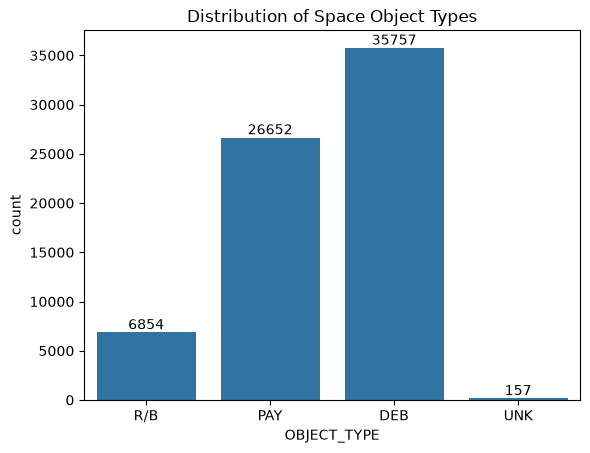

In [17]:
ax = sns.countplot(data=df,x='OBJECT_TYPE');

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Space Object Types")
plt.show()

In [18]:
(df['OBJECT_TYPE'].value_counts(normalize=True).mul(100).round(2))

OBJECT_TYPE
DEB    51.51
PAY    38.39
R/B     9.87
UNK     0.23
Name: proportion, dtype: float64

#### Observation:
- Most of the objects in the dataset are debris (DEB), making up about 67% of the total.
- Payloads (PAY) are the second largest group and include satellites and other working space objects.
- Rocket bodies (R/B) make up only a small part of the dataset, and Unknown (UNK) objects are very few.

### Distribution of Operational Status

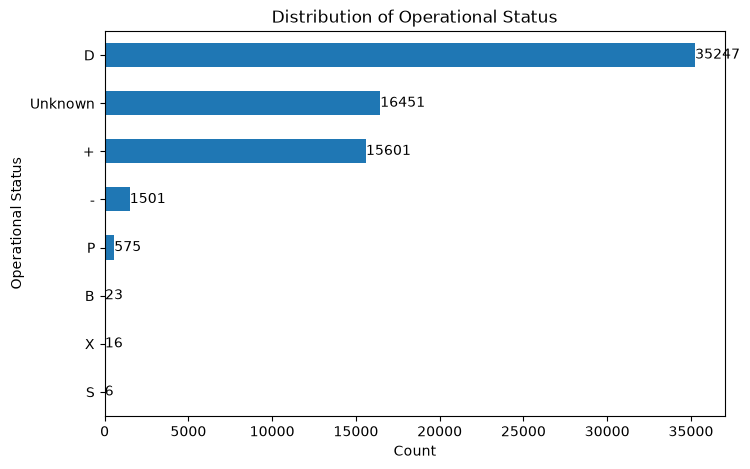

In [19]:
counts = df['OPS_STATUS_CODE'].value_counts().sort_values()

ax = counts.plot(kind='barh', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel('Count')
plt.ylabel('Operational Status')
plt.title('Distribution of Operational Status')
plt.show()

#### Observation:
- Most of the objects are decayed, which means they have already re-entered the Earth's atmosphere.
- A large number of objects have an Unknown status, which means their operational status is not available in the dataset.
- Operational objects are the third largest group, showing that many satellites and other space objects are still active.
- Non-operational and Partially Operational objects make up a smaller part of the dataset, while Backup, Extended Mission, and Spare objects are very few.

### Top 10 Owners of Space Objects

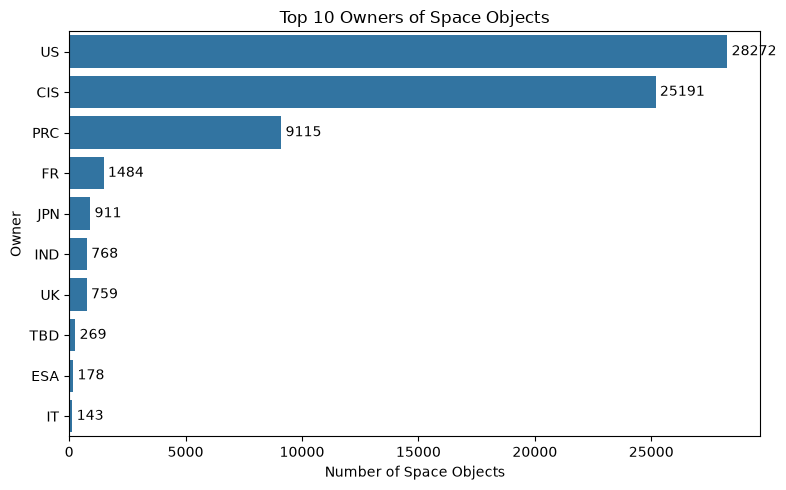

In [20]:
top_owner = df['OWNER'].value_counts().head(10)

plt.figure(figsize=(8,5))

ax = sns.barplot(x=top_owner.values,y=top_owner.index)

ax.bar_label(ax.containers[0],padding=3)

plt.xlabel('Number of Space Objects')
plt.ylabel('Owner')
plt.title('Top 10 Owners of Space Objects')
plt.tight_layout()
plt.show()

#### Observation:
- Plot shows that most of the space objects come from just a few countries and organizations.
- The United States, Russia (CIS-Commonwealth of Independent States), and China (PRC-People's Republic of China) have the highest number of space objects in the dataset.

### Top 10 Launch Sites by Number of Space Objects

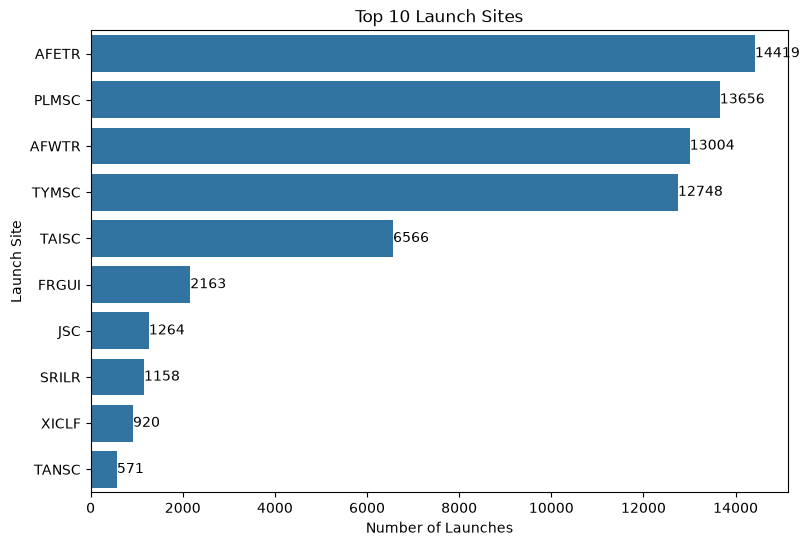

In [21]:
top_sites = df['LAUNCH_SITE'].value_counts().head(10)

plt.figure(figsize=(9,6))

ax = sns.barplot(x=top_sites.values,y=top_sites.index)

ax.bar_label(ax.containers[0])

plt.title("Top 10 Launch Sites")
plt.xlabel("Number of Launches")
plt.ylabel("Launch Site")
plt.show()

#### Observation:
- AFETR has the highest number of launches in the dataset, followed closely by PLMSC, AFWTR, and TYMSC.
- These four launch sites account for a large share of all recorded launches, while the remaining sites have much lower numbers.
- This shows that space launches are mainly concentrated at a few major launch sites around the world.

### Distribution of Orbital Period

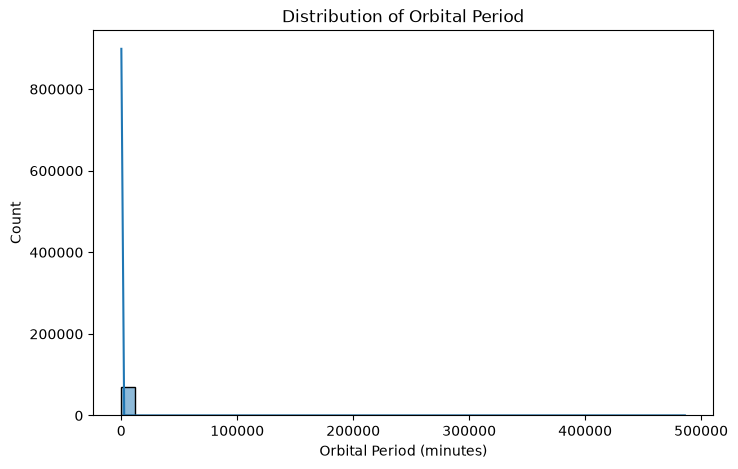

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,x='PERIOD',bins=40,kde=True)

plt.title("Distribution of Orbital Period")
plt.xlabel("Orbital Period (minutes)")
plt.show()

#### Observation:
Most objects have short orbital periods, while a few objects have extremely large periods, making the distribution highly right-skewed.

### Distribution of Orbital Period (Up to the 99th Percentile)

The original distributions contain a few extremely large values that compress most of the data into a small region. To better understand the distribution of the majority of observations, plot is made using 99th percentile.

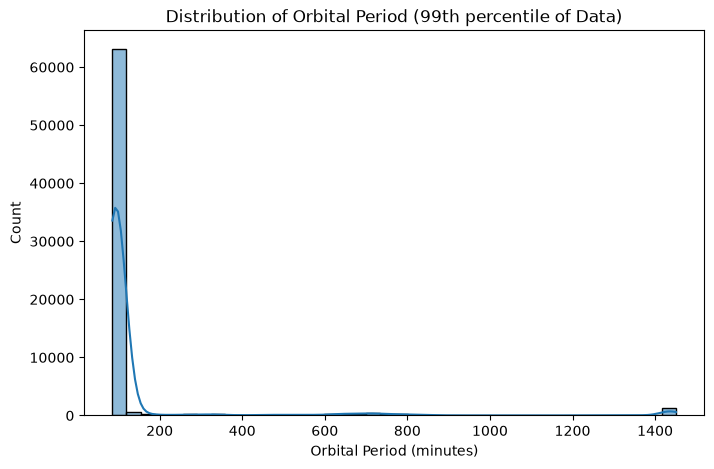

In [23]:
limit = df['PERIOD'].quantile(0.99)

plt.figure(figsize=(8,5))

sns.histplot(data=df[df['PERIOD'] <= limit],x='PERIOD',bins=40,kde=True)

plt.title("Distribution of Orbital Period (99th percentile of Data)")
plt.xlabel("Orbital Period (minutes)")
plt.ylabel("Count")

plt.show()

#### Observation:
- After removing only the most extreme values, the distribution becomes easier to understand. 
- Most objects have orbital periods close to 100 minutes.
- The number of objects decreases as the orbital period increases.
- A smaller group of objects has an orbital period close to 1440 minutes (24 hours), indicating objects in higher or geostationary orbits.

### Outlier Analysis of Numerical Features

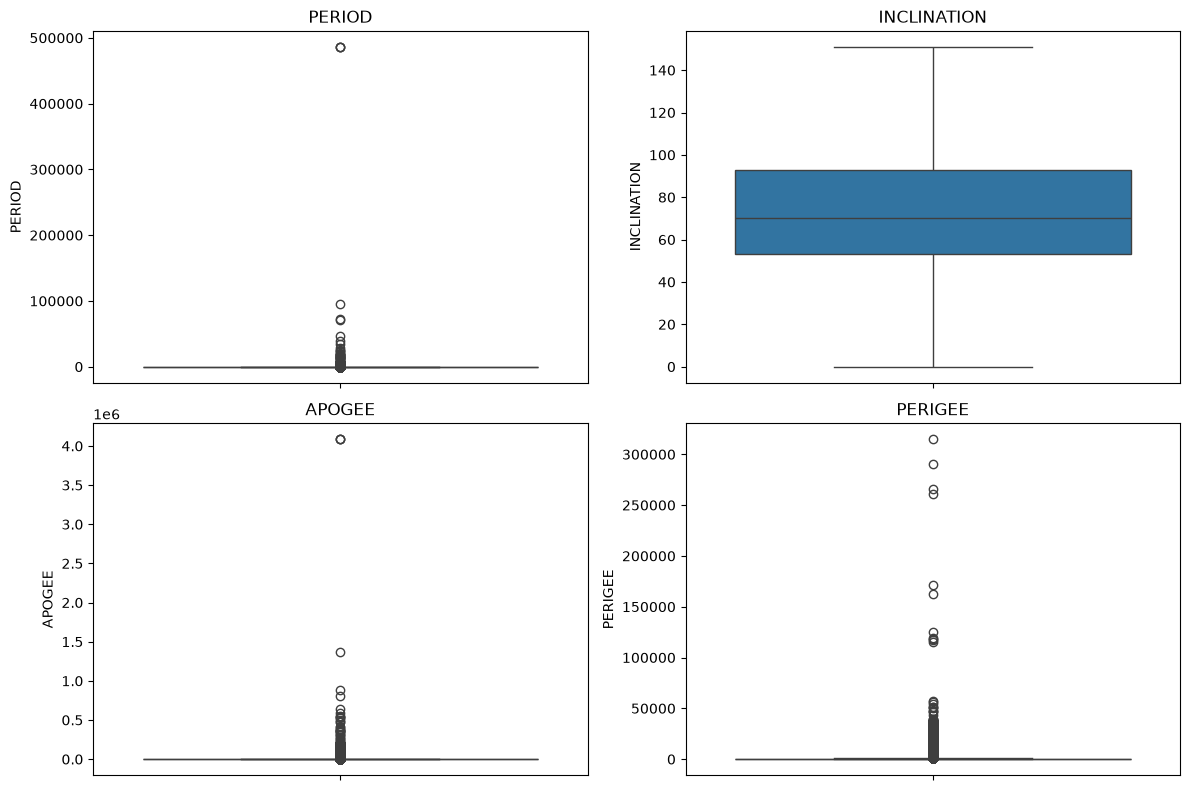

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = ['PERIOD', 'INCLINATION', 'APOGEE', 'PERIGEE']

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(y=df[feature], ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

#### Observation:

- Most space objects have orbital periods, apogee, and perigee values within a relatively small range, while a few objects have much larger values that appear as outliers.
- These extreme values make the main distribution appear compressed in the boxplots, showing that only a small number of objects have unusually high orbital characteristics.
- In contrast, the inclination values are more evenly spread and contain very few extreme values compared to the other numerical features.

### Launch Trends Over Time

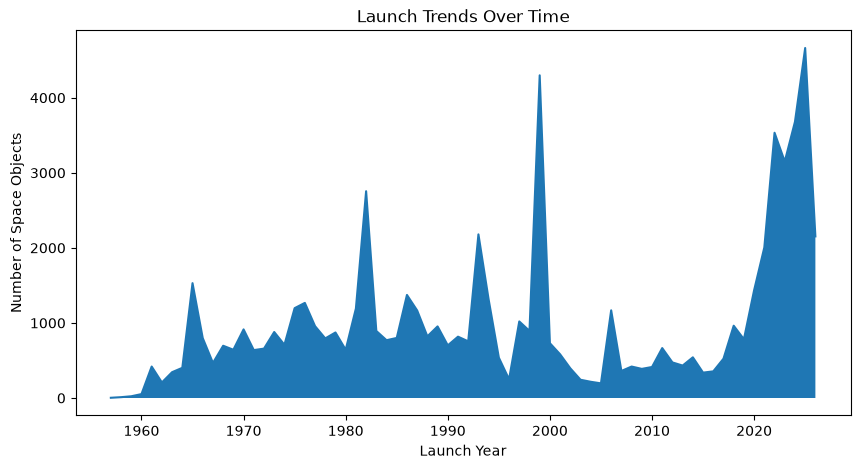

In [25]:
launches = df['LAUNCH_YEAR'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.fill_between(launches.index, launches.values)
plt.plot(launches.index, launches.values)

plt.title("Launch Trends Over Time")
plt.xlabel("Launch Year")
plt.ylabel("Number of Space Objects")

plt.show()

#### Observation:
- The number of launched space objects has increased over time, especially in recent years.
- A peak in the number of launched objects is also noticed aroung year 2000.

### Orbital Period Across Different Object Types (Upto 99th Percentile)

The original distributions contain a few extremely large values that compress most of the data into a small region. To better understand the distribution of the majority of observations, plot is made using 99th percentile.

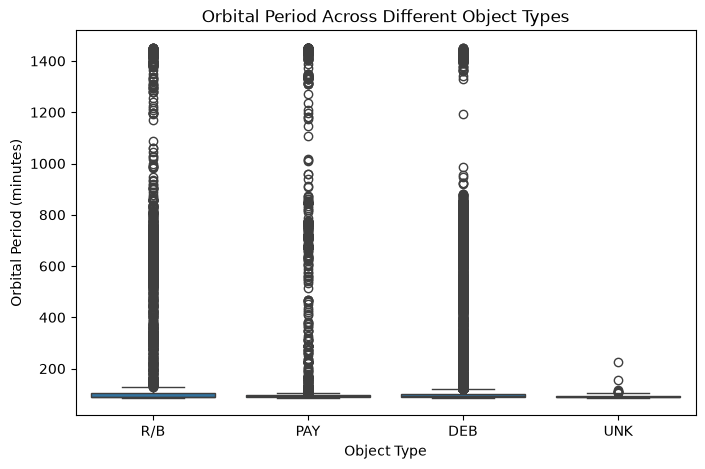

In [26]:
limit = df['PERIOD'].quantile(0.99)

plt.figure(figsize=(8,5))

sns.boxplot(data=df[df['PERIOD'] <= limit],x='OBJECT_TYPE',y='PERIOD')

plt.title("Orbital Period Across Different Object Types")
plt.xlabel("Object Type")
plt.ylabel("Orbital Period (minutes)")

plt.show()

#### Observation:
- Most payloads, rocket bodies, and debris have orbital periods within a similar range.
- All three object types also have some objects with longer orbital periods, which are shown as outliers.
- The Unknown category contains very few objects, so its distribution is much smaller than the other categories.
- Overall, orbital period alone does not clearly separate the different object types, suggesting that other features will also be important for classification.

### Inclination Across Different Object Types

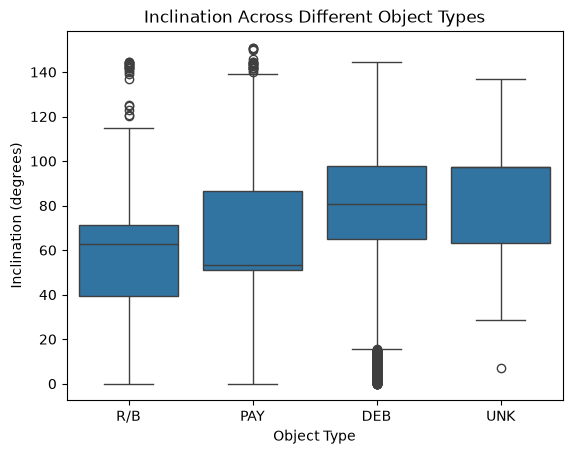

In [27]:
sns.boxplot(data=df,x='OBJECT_TYPE',y='INCLINATION')

plt.title("Inclination Across Different Object Types")
plt.xlabel("Object Type")
plt.ylabel("Inclination (degrees)")
plt.show()

#### Observation:
- Debris shows a higher inclination than payloads and rocket bodies.
- The Unknown category has very few objects, so it is difficult to draw any meaningful conclusion from it.
- Overall, inclination is different across the different object types.

### Relationship Between Perigee and Apogee (upto 99th Percentile)

The scatter plot is shown after limiting both perigee and apogee to their 99th percentile. This reduces the effect of extreme outliers and makes it easier to observe the relationship followed by the majority of space objects.

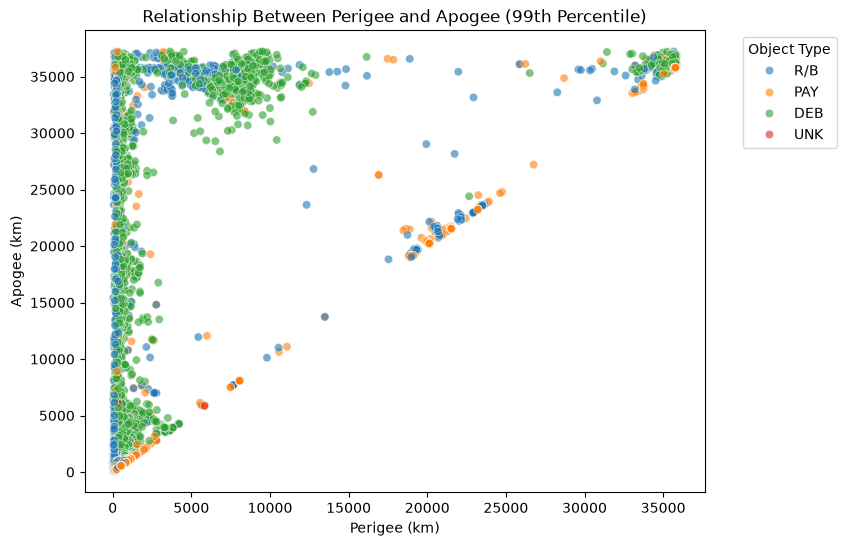

In [28]:
perigee_limit = df['PERIGEE'].quantile(0.99)
apogee_limit = df['APOGEE'].quantile(0.99)

filtered_df = df[(df['PERIGEE'] <= perigee_limit) &(df['APOGEE'] <= apogee_limit)]

plt.figure(figsize=(8,6))

sns.scatterplot(data=filtered_df,x='PERIGEE',y='APOGEE',hue='OBJECT_TYPE',alpha=0.6)

plt.title("Relationship Between Perigee and Apogee (99th Percentile)")
plt.xlabel("Perigee (km)")
plt.ylabel("Apogee (km)")
plt.legend(title="Object Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Observation:
- After removing only the most extreme 1% of values, the relationship becomes much easier to see.
- Most space objects have relatively low perigee values, while their apogee values cover a much wider range.
- As perigee increases, apogee also generally increases, showing a clear positive relationship between the two orbital parameters.
- The different object types overlap considerably, which suggests that perigee and apogee alone are not enough to clearly separate payloads, rocket bodies, and debris. Additional features will be needed for classification.

### Perigee and Apogee Across Object Types 

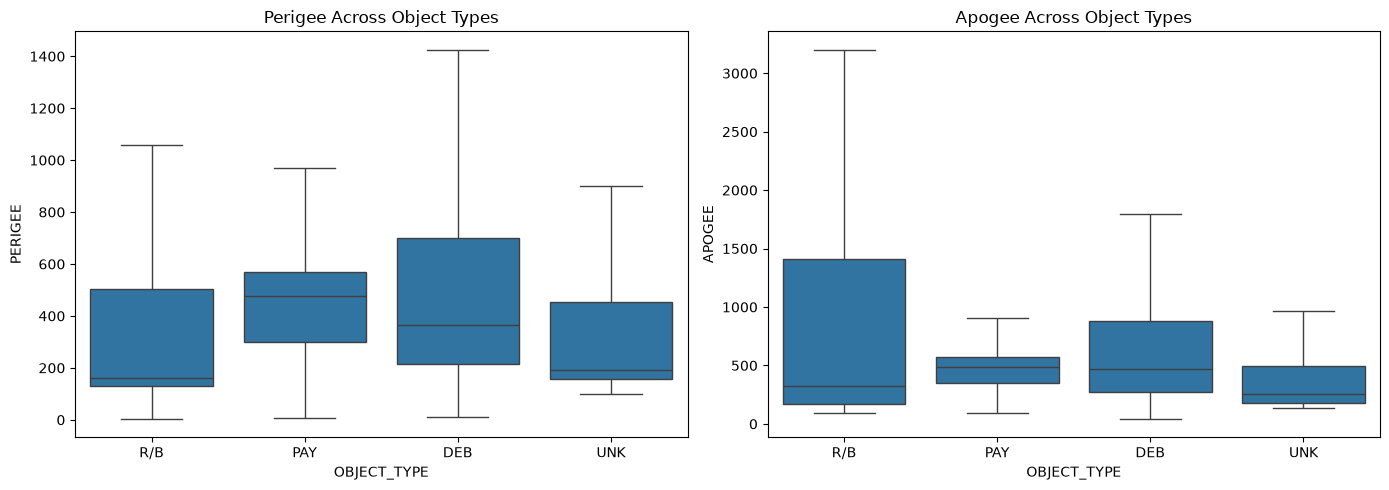

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df, x='OBJECT_TYPE', y='PERIGEE', ax=axes[0], showfliers=False)
axes[0].set_title("Perigee Across Object Types")

sns.boxplot(data=df, x='OBJECT_TYPE', y='APOGEE', ax=axes[1], showfliers=False)
axes[1].set_title("Apogee Across Object Types")

plt.tight_layout()
plt.show()

#### Observation:
- PAY has similar median values for both perigee and apogee, and the spread is relatively small. This indicates that PAY objects generally have more consistent orbital distances.
- R/B has a much higher spread in apogee than in perigee. This means rocket bodies have a wider variation in their highest orbital point.
- DEB shows the widest spread in perigee and also a large spread in apogee, indicating that debris is distributed across a broad range of orbital distances.
- UNK has a smaller spread in both perigee and apogee compared to the other object types. 

### Correlation Between Orbital Features

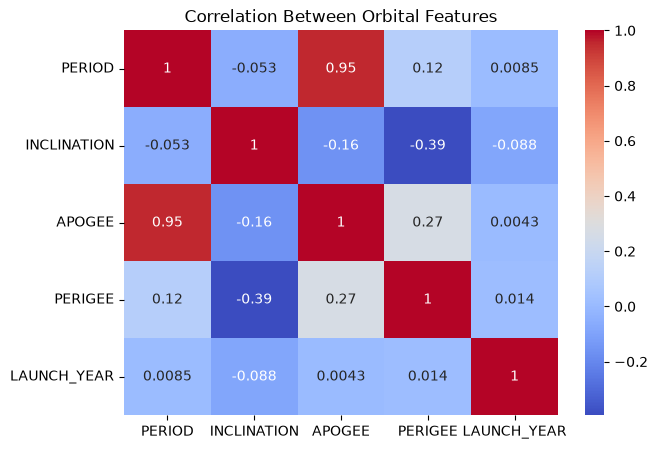

In [30]:
corr = df[['PERIOD','INCLINATION','APOGEE','PERIGEE','LAUNCH_YEAR']].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Between Orbital Features")
plt.show()

#### Observation:
- Orbital period and apogee are very strongly related, with a correlation of 0.95.
- Perigee shows only a weak positive relationship with both apogee and orbital period.
- Inclination has a moderate negative relationship with perigee, but its relationship with the other features is generally quite weak.
- Launch year shows very little correlation with the orbital features, which means these measurements are not strongly influenced by the year in which an object was launched.

### Relationship Between Apogee and Orbital Period

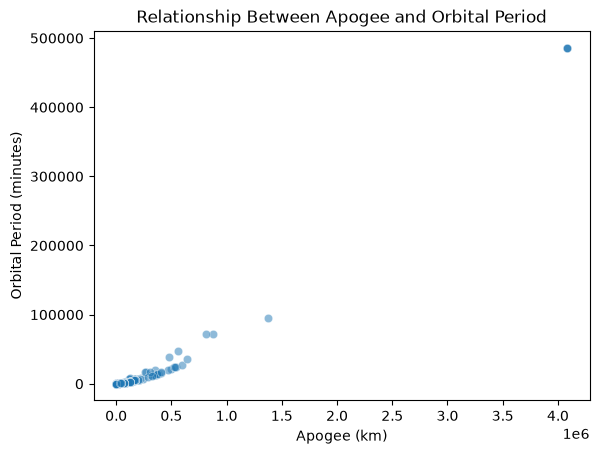

,APOGEE,PERIOD
APOGEE,1.000000,0.951525
PERIOD,0.951525,1.000000


In [31]:
sns.scatterplot(data=df,x='APOGEE',y='PERIOD',alpha=0.5)

plt.title("Relationship Between Apogee and Orbital Period")
plt.xlabel("Apogee (km)")
plt.ylabel("Orbital Period (minutes)")
plt.show()

# Correlation
df[['APOGEE', 'PERIOD']].corr()

#### Observation:
- Most space objects are clustered near the bottom-left of the plot, which means they have relatively low apogees and shorter orbital periods.
- As the apogee increases, the orbital period also increases. The clear upward trend in the points shows a strong positive relationship between these two features.
- A few objects are far away from the main cluster. These are objects with very high apogees and much longer orbital periods, but they make up only a small part of the dataset.

### Distribution of Object Types Over Time

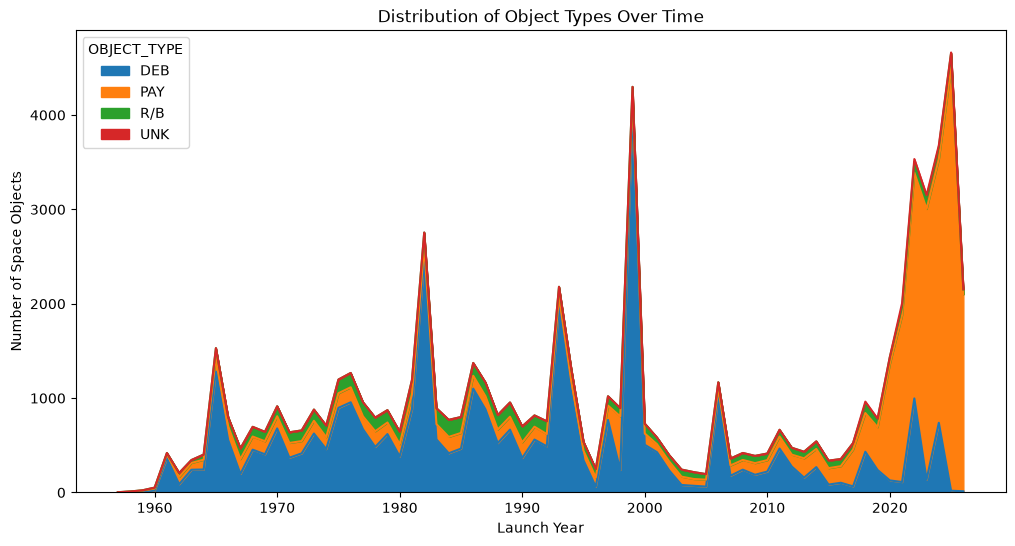

In [32]:
year_type = pd.crosstab(df['LAUNCH_YEAR'],df['OBJECT_TYPE'])

year_type.plot.area(figsize=(12,6))
plt.title("Distribution of Object Types Over Time")
plt.xlabel("Launch Year")
plt.ylabel("Number of Space Objects")
plt.show()

This is a stacked area chart. Total height shows how many objects were launched in that year.

#### Observation:
- The total number of space objects has generally increased over the years, although there are some years with noticeable ups and downs.
- Debris makes up a large portion of the objects for much of the timeline, especially in the earlier years.
- In recent years, the number of payloads has increased significantly and now makes up the largest share of the objects.
- Rocket bodies remain much fewer than debris and payloads throughout the timeline, while unknown objects appear only in very small numbers.

### Object Types Owned by Major Spacefaring Nations

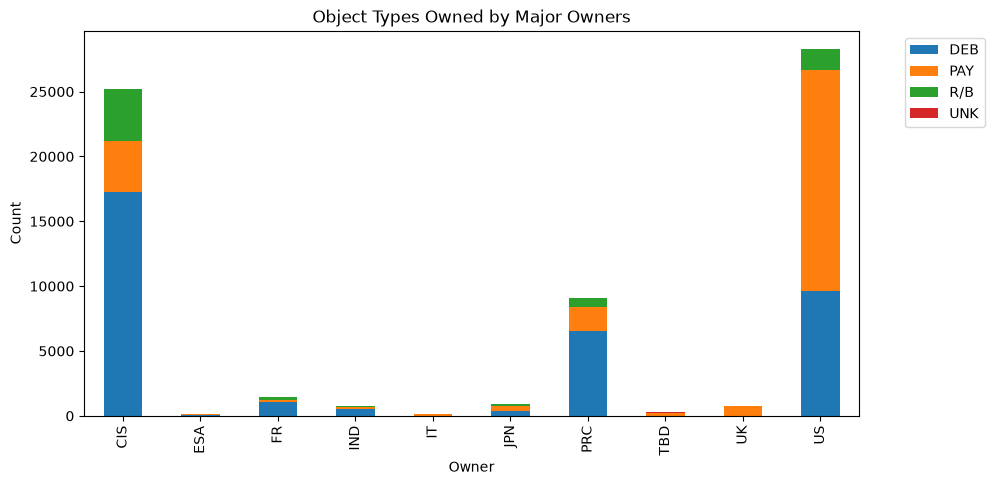

In [33]:
top_owner = df['OWNER'].value_counts().head(10).index

owner_type = pd.crosstab(
    df[df['OWNER'].isin(top_owner)]['OWNER'],
    df[df['OWNER'].isin(top_owner)]['OBJECT_TYPE'])

owner_type.plot(kind='bar',stacked=True,figsize=(10,5))

plt.title('Object Types Owned by Major Owners')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Owner')
plt.ylabel('Count')
plt.show()

#### Observation:
- The United States and CIS own far more space objects than any of the other owners in the dataset.
- Most of the objects owned by CIS are debris, while the United States has a much larger number of payloads than the other owners.
- China (PRC) also owns a large number of space objects (mostly debris), but still much fewer than the United States and CIS.
- France, India, Japan, and ESA own comparatively fewer space objects, and unknown object types make up only a very small part of the dataset.

---

## MACHINE LEARNING

### IMPORTING LIBRARIES 

In [42]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import pickle

### CREATING TARGET AND FEATURE VARIABLES

In [43]:
x = df.drop(columns=['OBJECT_NAME','OBJECT_ID','NORAD_CAT_ID','OBJECT_TYPE'])

y = df['OBJECT_TYPE']

OBJECT_NAME, OBJECT_ID, NORAD_CAT_ID columns were removed because they uniquely identify objects and do not contribute meaningful predictive information.

### ENCODING TARGET VARIABLE

In [44]:
le = LabelEncoder()
y = le.fit_transform(df['OBJECT_TYPE'])

In [45]:
# Display encoding mapping
encoding_mapping = dict(zip(le.classes_,
                            le.transform(le.classes_)))

print("Target Encoding Mapping:")
for label, value in encoding_mapping.items():
    print(f"{label} --> {value}")

Target Encoding Mapping:
DEB --> 0
PAY --> 1
R/B --> 2
UNK --> 3


### TRAIN TEST SPLIT

In [46]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

### ENCODING AND PREPROCESSING 

In [47]:
cat_cols = ['OPS_STATUS_CODE','OWNER','LAUNCH_SITE','ORBIT_CENTER','ORBIT_TYPE']

num_cols = ['PERIOD','INCLINATION','APOGEE','PERIGEE','LAUNCH_YEAR']

In [48]:
# For Logistic Regression, KNN, SVM

preprocessor_scaled = ColumnTransformer(
    [
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)


# For Decision Tree, Random Forest

preprocessor_tree = ColumnTransformer(
    [
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

Logistic Regression, KNN, and SVM are distance-based algorithms and therefore require feature scaling. Tree-based algorithms such as Decision Tree and Random Forest are scale-invariant, so only categorical encoding is applied.

### PIPELINE FOR MULTIPLE MODELS

In [49]:
models = {

    'Logistic Regression': Pipeline([
        ('prep', preprocessor_scaled),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),

    'KNN': Pipeline([
        ('prep', preprocessor_scaled),
        ('model', KNeighborsClassifier())
    ]),

    'SVM': Pipeline([
        ('prep', preprocessor_scaled),
        ('model', SVC(class_weight='balanced'))
    ]),

    'Decision Tree': Pipeline([
        ('prep', preprocessor_tree),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),

    'Random Forest': Pipeline([
        ('prep', preprocessor_tree),
        ('model', RandomForestClassifier(random_state=42))
    ]),

    'AdaBoost': Pipeline([
        ('prep', preprocessor_tree),
        ('model', AdaBoostClassifier(random_state=42))
    ]),

}

### TRAINING AND COMPARING MULTIPLE MODELS

In [50]:
results = []

trained_models = {}


for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred, average='weighted')
    })

    trained_models[name] = model

In [51]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(by='Accuracy',ascending=False)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
4,Random Forest,0.906871,0.904986,0.906871,0.905550
3,Decision Tree,0.881446,0.881829,0.881446,0.881623
1,KNN,0.879141,0.874501,0.879141,0.875408
2,SVM,0.785653,0.861399,0.785653,0.812418
5,AdaBoost,0.784284,0.782656,0.784284,0.775609
0,Logistic Regression,0.680351,0.828527,0.680351,0.729287


In [52]:
best_model = trained_models['Random Forest']

#### Observation:
- Six classification models were trained and evaluated using the same training and testing datasets.
- Random Forest achieved the highest baseline performance with an accuracy of 90.68%, outperforming Logistic Regression, KNN, SVM, AdaBoost and Decision Tree.
- Based on its performance, Random Forest was selected as the best model.

### TRAIN TEST ACCURACY

In [53]:
train_pred = best_model.predict(x_train)
test_pred = best_model.predict(x_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Train Accuracy :", round(train_accuracy, 4))
print("Test Accuracy  :", round(test_accuracy, 4))
print("Difference     :", round(train_accuracy - test_accuracy, 4))

Train Accuracy : 0.9961
Test Accuracy  : 0.9069
Difference     : 0.0893


#### Observation
- The baseline Random Forest achieved a training accuracy of 99.61% and a testing accuracy of 90.69%.
- The noticeable gap between training and testing accuracy indicated that the model was slightly overfitting the training data.
- Hyperparameter tuning will be performed to improve the model's generalization.

### HYPERPARAMETER TUNING

In [54]:
param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [10, 15, 20, 30, None],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=best_model,
    param_distributions=param_dist,
    n_iter=20,              
    cv=3,
    scoring='f1_weighted', 
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [10, 15, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Ra

In [55]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(random_search.best_score_)

best_rf = random_search.best_estimator_

Best Parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}

Best Cross-Validation F1 Score:
0.9010980627946442


### TRAIN TEST ACCURACY (TUNED MODEL)

In [56]:
print("Train:", best_rf.score(x_train, y_train))
print("Test :", best_rf.score(x_test, y_test))

Train: 0.9633931143762604
Test : 0.9075914721982138


#### Observation:
- RandomizedSearchCV reduced the train-test accuracy gap indicating reduced overfitting.
- The tuned Random Forest achieved a slightly higher test accuracy while maintaining good generalization.
Therefore, the tuned Random Forest was selected as the final model.

### EVALUATING TUNED MODEL 

In [57]:
y_pred = best_rf.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9075914721982138
Precision: 0.9063028972264335
Recall   : 0.9075914721982138
F1 Score : 0.9063115716623188

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      7151
           1       0.95      0.92      0.93      5331
           2       0.70      0.65      0.67      1371
           3       0.82      0.29      0.43        31

    accuracy                           0.91     13884
   macro avg       0.85      0.70      0.74     13884
weighted avg       0.91      0.91      0.91     13884


Confusion Matrix:

[[6800  123  228    0]
 [ 282 4901  146    2]
 [ 343  137  891    0]
 [   6    9    7    9]]


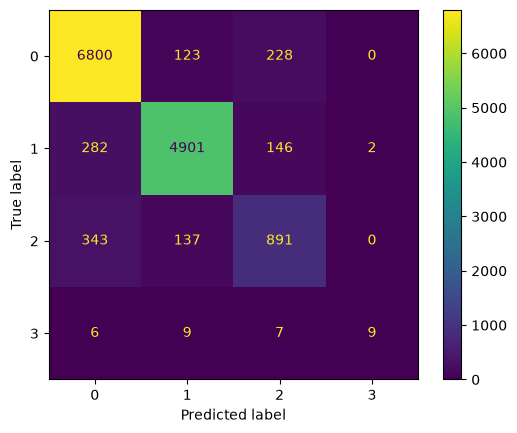

In [58]:
ConfusionMatrixDisplay.from_estimator(best_rf, x_test, y_test)
plt.show()

#### Observation:
- The confusion matrix shows that the model correctly predicted most of the satellite object types, as most values are on the diagonal.
- DEB was predicted the best, with 6800 correct predictions. Only a small number of DEB objects were predicted as PAY or R/B.
- PAY was also classified well, with 4901 correct predictions. Some PAY objects were confused with DEB and R/B.
- R/B had 891 correct predictions. A few Rocket Body objects were predicted as DEB or PAY, showing that these classes are sometimes similar.
- UNK had the fewest samples in the dataset, so the model found it more difficult to predict correctly. This is expected because the model had very little data to learn from for this class.
- Overall, the confusion matrix shows that the tuned Random Forest model performs well and correctly classifies most satellite objects, with only a few misclassifications.

### FEATURE IMPORTANCE

In [59]:
rf_model = best_rf.named_steps['model']
feature_names = best_rf.named_steps['prep'].get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
182,remainder__LAUNCH_YEAR,0.157620
181,remainder__PERIGEE,0.119697
179,remainder__INCLINATION,0.115379
0,cat__OPS_STATUS_CODE_+,0.097895
178,remainder__PERIOD,0.097151
180,remainder__APOGEE,0.093032
6,cat__OPS_STATUS_CODE_Unknown,0.064529
175,cat__ORBIT_TYPE_IMP,0.032794
3,cat__OPS_STATUS_CODE_D,0.027945
177,cat__ORBIT_TYPE_ORB,0.024631


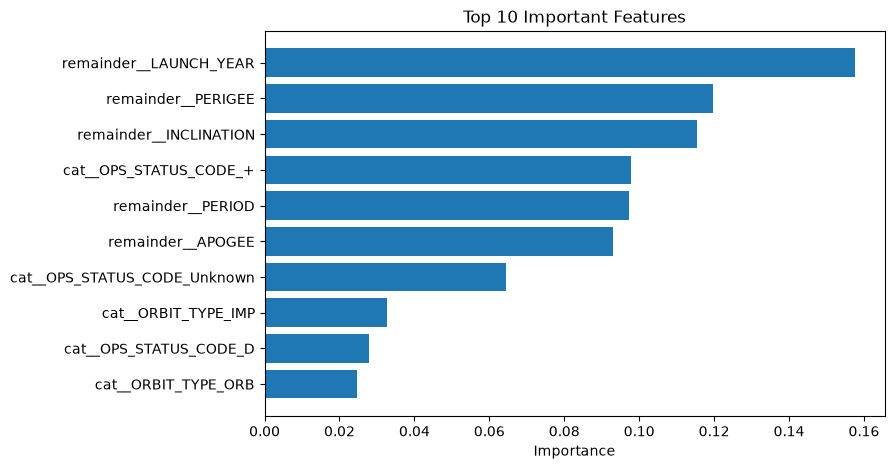

In [60]:
top10 = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10['Feature'], top10['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.show()

#### Observation
- The feature importance plot highlights the variables that contributed most to the Random Forest model's predictions.
- The most important features were PERIOD, APOGEE, PERIGEE, INCLINATION, and LAUNCH_YEAR, indicating that orbital characteristics play the biggest role in classifying space objects.

---

## SAVING THE MODEL

In [61]:
# Saving trained mode
with open("space_object_classifier.pkl", "wb") as file:
    pickle.dump(best_rf, file)

# Saving Label Encoder
with open("label_encoder.pkl", "wb") as file:
    pickle.dump(le, file)

print("Model and Label Encoder saved successfully!")

Model and Label Encoder saved successfully!


---

## CONCLUSION

This project successfully developed a Machine Learning model for classifying space objects based on their orbital and operational characteristics. Multiple classification algorithms were evaluated, and the Random Forest classifier achieved the best overall performance after hyperparameter tuning, with an accuracy of approximately **90.75%** and strong precision, recall, and F1-score. The final model was saved as a Pickle file, making it ready for integration into applications and future predictions without the need for retraining.